<h1 style="text-align:center;">AF3 Motif Builder</h1>

In [1]:
import glob
import os
import shutil
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from Bio.PDB import MMCIFParser
from Bio.SeqUtils import seq1

# Build motif

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4013882279.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4013882279.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4013882279.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair

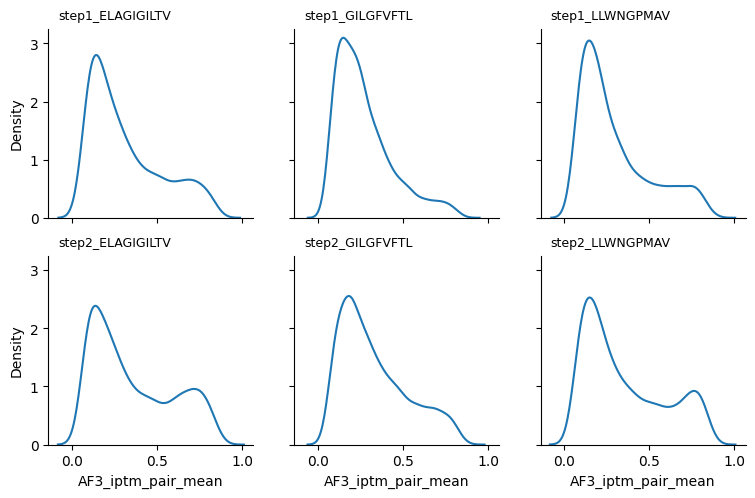

In [2]:
fig, axes = plt.subplots(2,3, figsize=(3*3,2.7*2), sharex=True, sharey=True)

steps = ['step1', 'step2']
peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']

for cnt1, step in enumerate(steps):
    for cnt2, peptide in enumerate(peptides):
        ax = axes[cnt1][cnt2]
        df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]

        sns.kdeplot(df, x='AF3_iptm_pair_mean', ax=ax)
        sns.despine()
        ax.text(0.05, 1.05, f'{step}_{peptide}', transform=ax.transAxes, fontsize=9)

In [3]:
# prepaire csv for motif building
steps = {'step1':0.5,
        'step2':0.8}

peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']

for step, threshold in steps.items():
    for peptide in peptides:
        df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
        anno = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)

        df = pd.merge(df, anno, on='id')
        df.to_csv(f'{step}_{peptide}/baseline.csv', index=False)
            
        df = df[df['AF3_iptm_pair_mean'] > threshold]
        df['model'] = peptide
        df.to_csv(f'{step}_{peptide}/model.csv', index=False) 

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/3201004643.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/3201004643.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/3201004643.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{step}_{peptide}/chainA_B_random_pair_{peptide}_output.txt', deli

# Curate file with CDR plddts for motif annotation

In [12]:
def extract_cdr_plddt(cif_path, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}, epitope_chains=["MHC","PEPTIDE"], threshold=10):
    """
    Extract plddt of CDRs based on the respective sequences.
    """

    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("cif", cif_path)
    model = structure[0]

    cdr_plddt = {}

    for chain_label, chain_id in chain_map.items():
        chain_obj = model[chain_id]

        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        seq = "".join(seq1(res.get_resname()) for res in residues)

        cdr_dict_chain = {}
        for key, value in cdr_dict.items():
            if key.endswith(chain_id[-1]):
                cdr_dict_chain[key] = value

        for cdr, cdr_seq in cdr_dict_chain.items():
            L = len(cdr_seq)

            start_idx = seq.find(cdr_seq)
            if start_idx == -1:
                print(f"Warning: {cdr} not found in {chain_id} of {cif_path}")
                continue

            end_idx = start_idx + L

            plddts = []
            for res in residues[start_idx:end_idx]:
                res_plddts = []
                for atom in res.get_atoms():
                    res_plddts.append(atom.get_bfactor())

                mean_res_plddts = np.mean(res_plddts) / 100
                plddts.append(np.round(mean_res_plddts, 2))

            cdr_plddt[cdr] = np.array(plddts) 

    return cdr_plddt

def split_cdr3(cdr3, v_gene, j_gene, v_ref, j_ref):
    """
    Split CDR3 into V, insertion, and J sequences.
    Returns: v_seq_str, insertion_seq_str, j_seq_str
    """
    # Get reference sequences
    v_seq = v_ref.loc[v_ref['Gene']==v_gene, 'CDR3'].values
    j_seq = j_ref.loc[j_ref['Gene']==j_gene, 'CDR3'].values
    
    if len(v_seq)==0 or len(j_seq)==0:
        # If reference is missing, put everything as 'Unknown'
        return None, None
    
    v_seq = v_seq[0]
    j_seq = j_seq[0]
    
    # Match V at the start
    v_len = 0
    for i in range(min(len(v_seq), len(cdr3))):
        if cdr3[i] == v_seq[i]:
            v_len += 1
        else:
            break
    
    # Match J at the end
    j_len = 0
    for i in range(1, min(len(j_seq), len(cdr3))+1):
        if cdr3[-i] == j_seq[-i]:
            j_len += 1
        else:
            break
    
    v_part = cdr3[:v_len]
    j_part = cdr3[len(cdr3)-j_len:] if j_len > 0 else ''
    insertion_part = cdr3[v_len:len(cdr3)-j_len] if len(cdr3) > v_len + j_len else ''
    
    # drop first C and last F/W
    v_part = v_part[1:]
    j_part = j_part[:-1]

    return v_part, j_part

In [14]:
peptides = ['ELAGIGILTV', 'GILGFVFTL', 'LLWNGPMAV']

for peptide in peptides:
    topdir = f'step2_{peptide}'
    df = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
    anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)
    df = pd.merge(df, anno, on='id')
    df = df[df['AF3_iptm_pair_mean'] > 0.8]
    df = df.rename(columns={'cdr3_TRA' : 'CDR3A', 'cdr3_TRB' : 'CDR3B'})

    genes = ['TRAV', 'TRBV']
    for gene in genes:
        anno = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/{gene}.csv')
        anno = anno.rename(columns={anno.columns[0]:gene})

        anno[f'CDR1{gene[-2]}'] = anno['CDR1'].str.replace('-', '', regex=False)
        anno[f'CDR2{gene[-2]}'] = anno['CDR2'].str.replace('-', '', regex=False)
        anno = anno[[gene, f'CDR1{gene[-2]}', f'CDR2{gene[-2]}']]

        df = pd.merge(df, anno, on=gene)

    # reference dataframes to split cdr3 according to V/J contributions
    TRAV_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRAV.csv').rename(columns={'Unnamed: 0':'Gene'})
    TRAJ_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRAJ.csv').rename(columns={'Unnamed: 0':'Gene'})
    TRBV_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRBV.csv').rename(columns={'Unnamed: 0':'Gene'})
    TRBJ_ref = pd.read_csv(f'../MixTCRviz/data_raw/HomoSapiens/TRBJ.csv').rename(columns={'Unnamed: 0':'Gene'})

    lst = []
    for idx, row in df.iterrows():
        cdr_dict = {cdr: str(row[cdr]).upper() for cdr in ["CDR1A","CDR2A","CDR3A","CDR1B","CDR2B","CDR3B"]}

        file = f'{topdir}/AF3_outputs/{row.id}/{row.id}_model.cif'
        
        cdr_plddts = extract_cdr_plddt(file, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}, epitope_chains=["MHC","PEPTIDE"])
        
        # add cdr3 v/j part
        v_part, j_part = split_cdr3(row.CDR3A, row.TRAV, row.TRAJ, TRAV_ref, TRAJ_ref)
        cdr_plddts['CDR3AV'] = cdr_plddts['CDR3A'][:len(v_part)]
        cdr_plddts['CDR3AJ'] = cdr_plddts['CDR3A'][-len(j_part):]

        v_part, j_part = split_cdr3(row.CDR3B, row.TRBV, row.TRBJ, TRBV_ref, TRBJ_ref)
        cdr_plddts['CDR3BV'] = cdr_plddts['CDR3B'][:len(v_part)]
        cdr_plddts['CDR3BJ'] = cdr_plddts['CDR3B'][-len(j_part):]

        cdr_plddts['id'] = row.id
        cdr_plddts['TRAV'] = row.TRAV
        cdr_plddts['TRAJ'] = row.TRAJ
        cdr_plddts['TRBV'] = row.TRBV
        cdr_plddts['TRBJ'] = row.TRBJ
        cdr_plddts['CDR3A_seq'] = row.CDR3A
        cdr_plddts['CDR3B_seq'] = row.CDR3B
        lst.append(cdr_plddts)

    df = pd.DataFrame(lst)   
    df.to_csv(f'{topdir}/cdr_plddts.csv', index=False)

/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4032854266.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id', 'AF3_iptm_pair_mean']]
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4032854266.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  anno = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_input.txt', delim_whitespace=True)
/var/folders/2v/m8p5rbh538sgyrgvrcyb210h0000gn/T/ipykernel_95793/4032854266.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f'{topdir}/chainA_B_random_pair_{peptide}_output.txt', delim_whitespace=True)[['id',